In [127]:
import numpy as np
import matplotlib.pyplot as plt

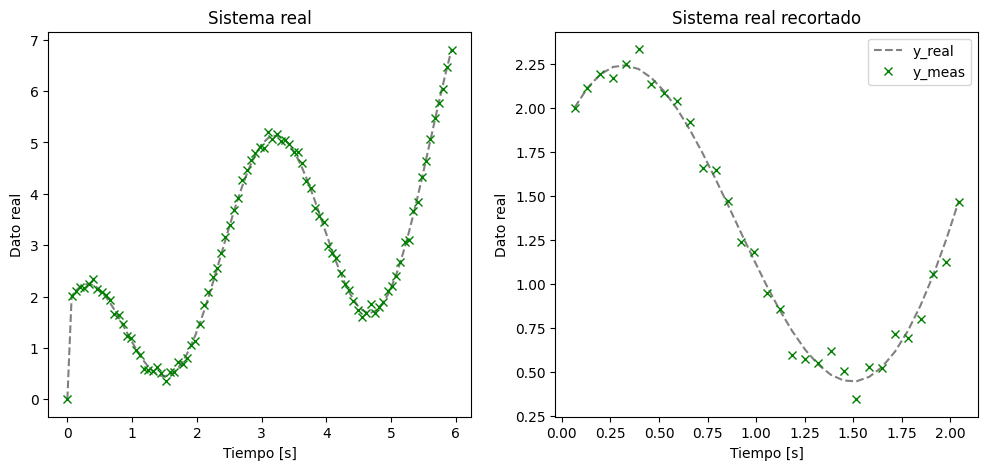

In [128]:
# Primero simulemos el sistema "real"
M = 91
std = [0., 0.08] # Los primeros 3 tienen menos error
delta = 6/M
y = np.zeros((M,1))
y_meas = np.zeros((M,1))

# PHI - GAMMA
x = [0.9967, 0.9556, 2.0030] # Coeficientes de las h (en este caso, y-u)

t = np.arange(M) * delta

for j in range(1,M):
    y[j] = x[0] * t[j-1] + x[1] * np.sin(t[j-1]) + x[2] * np.cos(2*t[j-1])
    if j <= 3:
        y_meas[j] = y[j] + np.random.normal(0, std[0])
    else:
        y_meas[j] = y[j] + np.random.normal(0, std[1])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Sistema real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t, y, '--', c='gray', label='y_real')
plt.plot(t, y_meas, 'x', c='green', label='y_meas')

t, y = t[1:32], y[1:32]
y_meas = y_meas[1:32]
plt.subplot(1,2,2)
plt.title("Sistema real recortado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t, y, '--', c='gray', label='y_real')
plt.plot(t, y_meas, 'x', c='green', label='y_meas')
plt.legend()
plt.show()

In [129]:
ws = [1, 10, 100, 1e5, 1e7]
X_est = []
Y_est = []

for i in range(len(ws)):
    w = ws[i]

    W = np.ones_like(y[1:])
    W[:3] = w
    W = np.eye(W.shape[0]) * np.sqrt(W)

    h1 = t.copy().reshape(-1,1)[:-1]
    h2 = np.sin(t).reshape(-1,1)[:-1]
    h3 = np.cos(2*t).reshape(-1,1)[:-1]
    H = np.hstack((h1,h2,h3))

    x_est = np.linalg.inv(H.T @ W @ H) @ H.T @ W @ y_meas[1:]
    X_est.append(x_est)

    y_est = np.zeros((y.shape[0],1))
    for j in range(1,y.shape[0]):
        y_est[j] = x_est[0] * t[j-1] + x_est[1] * np.sin(t[j-1]) + x_est[2] * np.cos(2*t[j-1])
    Y_est.append(y_est)

x_real = np.array(x).reshape(-1,1)

print("\nComparación de parámetros:\n")
print(f"{'w':>10} | {'x_est':>27} | {'error':>35}")
print("-"*90)

for i, w in enumerate(ws):
    x_e = X_est[i]
    error = x_e - x_real

    x_e_flat = x_e.flatten()
    err_flat = error.flatten()

    print(f"{w:>10.1e} | "
          f"[{x_e_flat[0]: .4f}, {x_e_flat[1]: .4f}, {x_e_flat[2]: .4f}] | "
          f"[{err_flat[0]: .4e}, {err_flat[1]: .4e}, {err_flat[2]: .4e}]")


Comparación de parámetros:

         w |                       x_est |                               error
------------------------------------------------------------------------------------------
   1.0e+00 | [ 0.9483,  1.0170,  1.9998] | [-4.8399e-02,  6.1386e-02, -3.2075e-03]
   1.0e+01 | [ 0.9432,  1.0187,  1.9918] | [-5.3451e-02,  6.3102e-02, -1.1215e-02]
   1.0e+02 | [ 0.9457,  1.0100,  1.9865] | [-5.0969e-02,  5.4397e-02, -1.6512e-02]
   1.0e+05 | [ 1.1804,  0.6269,  2.0023] | [ 1.8375e-01, -3.2868e-01, -6.8930e-04]
   1.0e+07 | [ 1.5460,  0.0338,  2.0329] | [ 5.4929e-01, -9.2184e-01,  2.9867e-02]


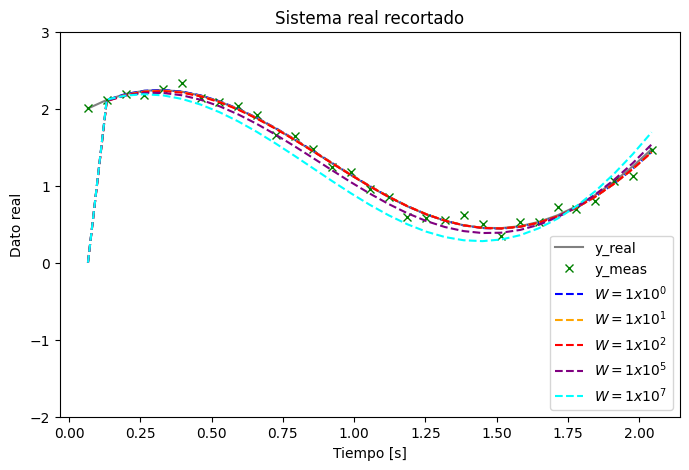

In [130]:
plt.figure(figsize=(8,5))
plt.title("Sistema real recortado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t, y, c='gray', label='y_real')
plt.plot(t, y_meas, 'x', c='green', label='y_meas')

colores = ['blue', 'orange', 'red', 'purple', 'cyan']
labels = [
    '$W = 1 x 10^0$',
    '$W = 1 x 10^1$',
    '$W = 1 x 10^2$',
    '$W = 1 x 10^5$',
    '$W = 1 x 10^7$'
]
for idx in range(len(Y_est)):
    plt.plot(t, Y_est[idx], '--', c=colores[idx], label=labels[idx])
plt.ylim(-2,3)
plt.legend()
plt.show()